# 🎰 Simulador de Pools - Lotofácil

Notebook interativo para testar diferentes combinações de números no pool de 19.

**Como usar:**
1. Execute as células de configuração inicial (Seção 1 e 2)
2. Modifique a lista `POOL_TESTE` na Seção 3 com os números que deseja testar
3. Execute a análise (Seção 4) e veja os resultados
4. Compare com outros pools (Seção 7)

**Exemplo:** Para testar trocar 22 por 23, basta modificar a lista na Seção 3

## 1️⃣ Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from collections import Counter

# Configuração de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2️⃣ Carregar Dados Históricos

In [2]:
# Carregar resultados históricos
df = pd.read_csv('data/lotofacil_sorteios.csv')

# Converter data
df['Data Sorteio'] = pd.to_datetime(df['Data Sorteio'], format='%d/%m/%Y')

# Criar conjunto de números para cada concurso
df['numeros_set'] = df.apply(
    lambda row: set([row[f'Bola{i}'] for i in range(1, 16)]), 
    axis=1
)

print(f"✅ Dados carregados: {len(df)} concursos")
print(f"📅 Período: {df['Data Sorteio'].min().strftime('%d/%m/%Y')} até {df['Data Sorteio'].max().strftime('%d/%m/%Y')}")
print(f"\n🔢 Total de números disponíveis: 25")
print(f"📊 Números por sorteio: 15")

✅ Dados carregados: 3581 concursos
📅 Período: 29/09/2003 até 07/01/2026

🔢 Total de números disponíveis: 25
📊 Números por sorteio: 15


### 📋 Últimos 5 Resultados

In [3]:
# Mostrar os últimos 10 sorteios
print("🎰 ÚLTIMOS 10 SORTEIOS DA LOTOFÁCIL")
print("="*100)

ultimos_10 = df.tail(10).sort_values('Concurso', ascending=False)

for idx, row in ultimos_10.iterrows():
    concurso = row['Concurso']
    data = row['Data Sorteio'].strftime('%d/%m/%Y')
    numeros = sorted([row[f'Bola{i}'] for i in range(1, 16)])
    
    print(f"\n📅 Concurso {concurso} - {data}")
    print(f"   Números: {' - '.join([f'{n:02d}' for n in numeros])}")

print("\n" + "="*100)

🎰 ÚLTIMOS 10 SORTEIOS DA LOTOFÁCIL

📅 Concurso 3581 - 07/01/2026
   Números: 02 - 03 - 04 - 05 - 06 - 07 - 08 - 10 - 12 - 15 - 16 - 17 - 20 - 22 - 24

📅 Concurso 3580 - 06/01/2026
   Números: 01 - 04 - 05 - 06 - 08 - 09 - 12 - 13 - 15 - 16 - 19 - 20 - 21 - 23 - 25

📅 Concurso 3579 - 05/01/2026
   Números: 01 - 02 - 03 - 04 - 08 - 10 - 11 - 13 - 15 - 17 - 19 - 20 - 21 - 23 - 25

📅 Concurso 3578 - 03/01/2026
   Números: 02 - 03 - 04 - 05 - 06 - 07 - 09 - 10 - 14 - 17 - 19 - 20 - 22 - 23 - 24

📅 Concurso 3577 - 02/01/2026
   Números: 01 - 02 - 04 - 05 - 06 - 08 - 09 - 10 - 12 - 16 - 18 - 20 - 23 - 24 - 25

📅 Concurso 3576 - 01/01/2026
   Números: 01 - 02 - 03 - 05 - 07 - 08 - 10 - 13 - 16 - 18 - 19 - 21 - 22 - 23 - 25

📅 Concurso 3575 - 30/12/2025
   Números: 02 - 04 - 05 - 07 - 08 - 09 - 10 - 12 - 13 - 14 - 15 - 17 - 21 - 22 - 25

📅 Concurso 3574 - 29/12/2025
   Números: 01 - 03 - 04 - 05 - 06 - 08 - 12 - 13 - 15 - 16 - 17 - 18 - 20 - 21 - 25

📅 Concurso 3573 - 27/12/2025
   Números: 01 

## 3️⃣ DEFINA SEU POOL AQUI 🎯

**Modifique a lista `POOL_TESTE` abaixo com os 19 números que deseja testar!**

Exemplos:
- Pool ótimo atual: `[1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]`
- Trocar 22 por 23: `[1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 23, 24, 25]`
- Trocar 10 por 5: `[1, 2, 3, 4, 5, 6, 9, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]`

In [58]:
# 🎯 MODIFIQUE AQUI: Coloque os 19 números que deseja testar
#POOL_TESTE = [1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]
#POOL_TESTE = [1,2,3,4,5,8,9,10,13,14,15,16,17,19,20,25]
# Pools de  15 acertos 
#POOL_TESTE = [2,3,4,5,6,7,8,10,12,15,16,17,20,22,23,24]
# pool jogado 1 
#POOL_TESTE=[2,3,4,5,6,7,8,10,12,15,16,17,19,20,22,23,24]
#POOL_TESTE=[2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 16, 17, 19, 20, 22, 23, 24,25]
#POOL_TESTE=[2, 3, 4, 5, 6, 7, 8,10, 12, 15, 16, 17, 19, 20, 22, 24]
POOL_TESTE=[1, 2, 4, 5, 10, 13, 15, 16, 17, 19, 20, 21, 22, 23, 25]

# Validação automática
assert len(POOL_TESTE) == 15, f"❌ Pool deve ter 19 números! Você tem {len(POOL_TESTE)}"
assert len(set(POOL_TESTE)) == 15, "❌ Pool tem números duplicados!"
assert all(1 <= n <= 25 for n in POOL_TESTE), "❌ Números devem estar entre 1 e 25!"
assert all(isinstance(n, int) for n in POOL_TESTE), "❌ Todos os valores devem ser números inteiros!"

print("✅ Pool válido!")
print(f"\n🎯 Pool de teste ({len(POOL_TESTE)} números):")
print(f"   {sorted(POOL_TESTE)}")
print(f"\n❌ Números excluídos ({25 - len(POOL_TESTE)} números):")
excluidos = sorted(set(range(1, 26)) - set(POOL_TESTE))
print(f"   {excluidos}")

✅ Pool válido!

🎯 Pool de teste (15 números):
   [1, 2, 4, 5, 10, 13, 15, 16, 17, 19, 20, 21, 22, 23, 25]

❌ Números excluídos (10 números):
   [3, 6, 7, 8, 9, 11, 12, 14, 18, 24]


3581,07/01/2026,1,2,4,5,6,8,9,10,13,15,17,19,20,21,23,25
3581,07/01/2026,3,5,7,10,14,15,16,17,18,19,20,22,23,24,25
3581,07/01/2026,1,2,3,4,5,6,8,9,10,13,16,19,20,21,23,25

3581,07/01/2026,2,3,4,5,6,7,8,10,12,15,16,17,20,22,24

3581,07/01/2026,1,2,4,5,6,8,9,10,13,15,17,19,20,21,23,25
sairam: 2,4,5,6,8,10,15,17,20 
não saíram: 1,9,13,19,21,23,25 

3581,07/01/2026,3,5,7,10,14,15,16,17,18,19,20,22,23,24,25
saíram: 3,5,7,10,15,17,20,22,24 
não saíram: 14,18,19,23,25

3581,07/01/2026,1,2,3,4,5,6,8,9,10,13,16,19,20,21,23,25
saíram: 2,3,4,5,6,8,10,16,17,20
não saíram: 1,9,13,19,21,23,25

1,2,3,4,5,6,8,10,12,13,14,15,16,17,20

2,3,4,5,6,7,8,10,12,15,16,17,20,22,23,24
1,3,4,5,6,7,8,10,12,15,16,17,20,22,23,24 

4
3
3
3
2

2,3,4,5,6,7,8,10,12,15,16,17,20,22,24
1,3,4,5,6,7,8,10,12,15,16,17,20,22,24

2,3,5,9,10,11,18,19,20,21,22,23,24,25

2,3,4,5,6,7,8,10 - 8
12,15,16,17 - 4
20,22,23,24 - 4

1,3,4,5,6,7,8,10 - 8
12,15,16,17 - 4
20,22,23,24 - 4

2,3,4,5,6,7,8,10 - 8
12,15,16,17 - 4
20,22,24 - 3

1,3,4,5,6,7,8,10 - 8
12,15,16,17 - 4
20,22,24 - 3

5,6,7,8,9,10,12,14,15,16,20,21,22,23,24
5,6,7,8,9,10,12,13,14,15,20,21,22,23,25

## 4️⃣ Executar Análise do Pool

Análise completa do pool configurado acima

In [59]:
def analisar_pool(pool, df, nome_pool="Pool Teste"):
    """
    Analisa um pool de números contra o histórico da Lotofácil
    
    Returns:
        dict com todas as estatísticas do pool
    """
    pool_set = set(pool)
    
    # Calcular acertos para cada concurso
    df['acertos'] = df['numeros_set'].apply(lambda x: len(x & pool_set))
    
    # Estatísticas gerais
    total_concursos = len(df)
    jogos_perfeitos = df[df['acertos'] == 15]
    jogos_14 = df[df['acertos'] == 14]
    jogos_13_plus = df[df['acertos'] >= 13]
    
    # Últimos 50 sorteios
    ultimos_50 = df.tail(30)
    media_ultimos_50 = ultimos_50['acertos'].mean()
    
    # Últimos 20 sorteios
    ultimos_20 = df.tail(20)
    media_ultimos_20 = ultimos_20['acertos'].mean()
    
    # Distribuição de acertos
    distribuicao = df['acertos'].value_counts().sort_index()
    
    # Resultados
    resultados = {
        'nome': nome_pool,
        'pool': sorted(pool),
        'total_concursos': total_concursos,
        'perfeitos': len(jogos_perfeitos),
        'perfeitos_pct': (len(jogos_perfeitos) / total_concursos) * 100,
        'jogos_14': len(jogos_14),
        'jogos_14_pct': (len(jogos_14) / total_concursos) * 100,
        'jogos_13_plus': len(jogos_13_plus),
        'jogos_13_plus_pct': (len(jogos_13_plus) / total_concursos) * 100,
        'media_geral': df['acertos'].mean(),
        'media_ultimos_50': media_ultimos_50,
        'media_ultimos_20': media_ultimos_20,
        'distribuicao': distribuicao,
        'df_analise': df.copy(),
        'jogos_perfeitos_detalhes': jogos_perfeitos[['Concurso', 'Data Sorteio']].to_dict('records') if len(jogos_perfeitos) > 0 else []
    }
    
    return resultados

# Executar análise
print("⏳ Analisando pool...")
resultado = analisar_pool(POOL_TESTE, df.copy(), nome_pool="Pool Teste")

# Exibir resultados principais
print("\n" + "="*70)
print(f"📊 RESULTADOS DA ANÁLISE - {resultado['nome']}")
print("="*70)
print(f"\n🎯 Pool testado: {resultado['pool']}")
print(f"\n🏆 JOGOS PERFEITOS (15/15):")
print(f"   Total: {resultado['perfeitos']} jogos ({resultado['perfeitos_pct']:.2f}%)")

if resultado['perfeitos'] > 0:
    print(f"\n   📅 Concursos com 15 acertos:")
    for jogo in resultado['jogos_perfeitos_detalhes']:
        data_str = pd.to_datetime(jogo['Data Sorteio']).strftime('%d/%m/%Y')
        print(f"      • Concurso {jogo['Concurso']:>4} - {data_str}")

print(f"\n⭐ 14 Acertos:")
print(f"   Total: {resultado['jogos_14']} jogos ({resultado['jogos_14_pct']:.2f}%)")

print(f"\n✅ 13+ Acertos (13, 14 ou 15):")
print(f"   Total: {resultado['jogos_13_plus']} jogos ({resultado['jogos_13_plus_pct']:.2f}%)")

print(f"\n📈 MÉDIAS DE ACERTOS:")
print(f"   Histórico completo: {resultado['media_geral']:.2f}/15")
print(f"   Últimos 30 sorteios: {resultado['media_ultimos_50']:.2f}/15 ({(resultado['media_ultimos_50']/15)*100:.1f}%)")
print(f"   Últimos 20 sorteios: {resultado['media_ultimos_20']:.2f}/15 ({(resultado['media_ultimos_20']/15)*100:.1f}%)")

print(f"\n📊 DISTRIBUIÇÃO DE ACERTOS:")
for acertos in sorted(resultado['distribuicao'].keys(), reverse=True):
    qtd = resultado['distribuicao'][acertos]
    pct = (qtd / resultado['total_concursos']) * 100
    barra = '█' * int(pct)
    print(f"   {acertos:2d} acertos: {qtd:4d} jogos ({pct:5.2f}%) {barra}")

print("="*70)

⏳ Analisando pool...

📊 RESULTADOS DA ANÁLISE - Pool Teste

🎯 Pool testado: [1, 2, 4, 5, 10, 13, 15, 16, 17, 19, 20, 21, 22, 23, 25]

🏆 JOGOS PERFEITOS (15/15):
   Total: 0 jogos (0.00%)

⭐ 14 Acertos:
   Total: 0 jogos (0.00%)

✅ 13+ Acertos (13, 14 ou 15):
   Total: 3 jogos (0.08%)

📈 MÉDIAS DE ACERTOS:
   Histórico completo: 9.02/15
   Últimos 30 sorteios: 9.43/15 (62.9%)
   Últimos 20 sorteios: 9.65/15 (64.3%)

📊 DISTRIBUIÇÃO DE ACERTOS:
   13 acertos:    3 jogos ( 0.08%) 
   12 acertos:   51 jogos ( 1.42%) █
   11 acertos:  309 jogos ( 8.63%) ████████
   10 acertos:  857 jogos (23.93%) ███████████████████████
    9 acertos: 1199 jogos (33.48%) █████████████████████████████████
    8 acertos:  801 jogos (22.37%) ██████████████████████
    7 acertos:  307 jogos ( 8.57%) ████████
    6 acertos:   49 jogos ( 1.37%) █
    5 acertos:    5 jogos ( 0.14%) 


## 5️⃣ Testar Múltiplas Variações

Teste rapidamente múltiplas trocas de números

In [11]:
# Define o pool base e as variações que deseja testar
POOL_BASE = [1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]

# Lista de trocas: (número_sai, número_entra, nome_descritivo)
TROCAS_TESTAR = [
    (22, 23, "Trocar 22→23"),
    # (10, 5, "Trocar 10→5"),
    # (24, 7, "Trocar 24→7"),
    # s(25, 8, "Trocar 25→8"),
    # Adicione mais trocas aqui
]

# Executar todas as simulações
print("⏳ Testando múltiplas variações...\n")
resultados_comparacao = []

# Primeiro, adicionar o pool base
res_base = analisar_pool(POOL_BASE, df.copy(), "Pool Base (Original)")
resultados_comparacao.append(res_base)

# Testar cada variação
for num_sai, num_entra, descricao in TROCAS_TESTAR:
    if num_sai in POOL_BASE:
        pool_variacao = [n if n != num_sai else num_entra for n in POOL_BASE]
        res = analisar_pool(pool_variacao, df.copy(), descricao)
        resultados_comparacao.append(res)
        print(f"✅ {descricao}")

print(f"\n✅ {len(resultados_comparacao)} pools analisados!")

⏳ Testando múltiplas variações...

✅ Trocar 22→23

✅ 2 pools analisados!


## 6️⃣ Visualizar Resultados

Gráficos comparativos dos pools testados

C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_26412\849630224.py:50: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_26412\849630224.py:50: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_26412\849630224.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\wmaldonado\AppData\Local\Temp\ipykernel_26412\849630224.py:50: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
f:\projetos\2026\lotofacil\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM S

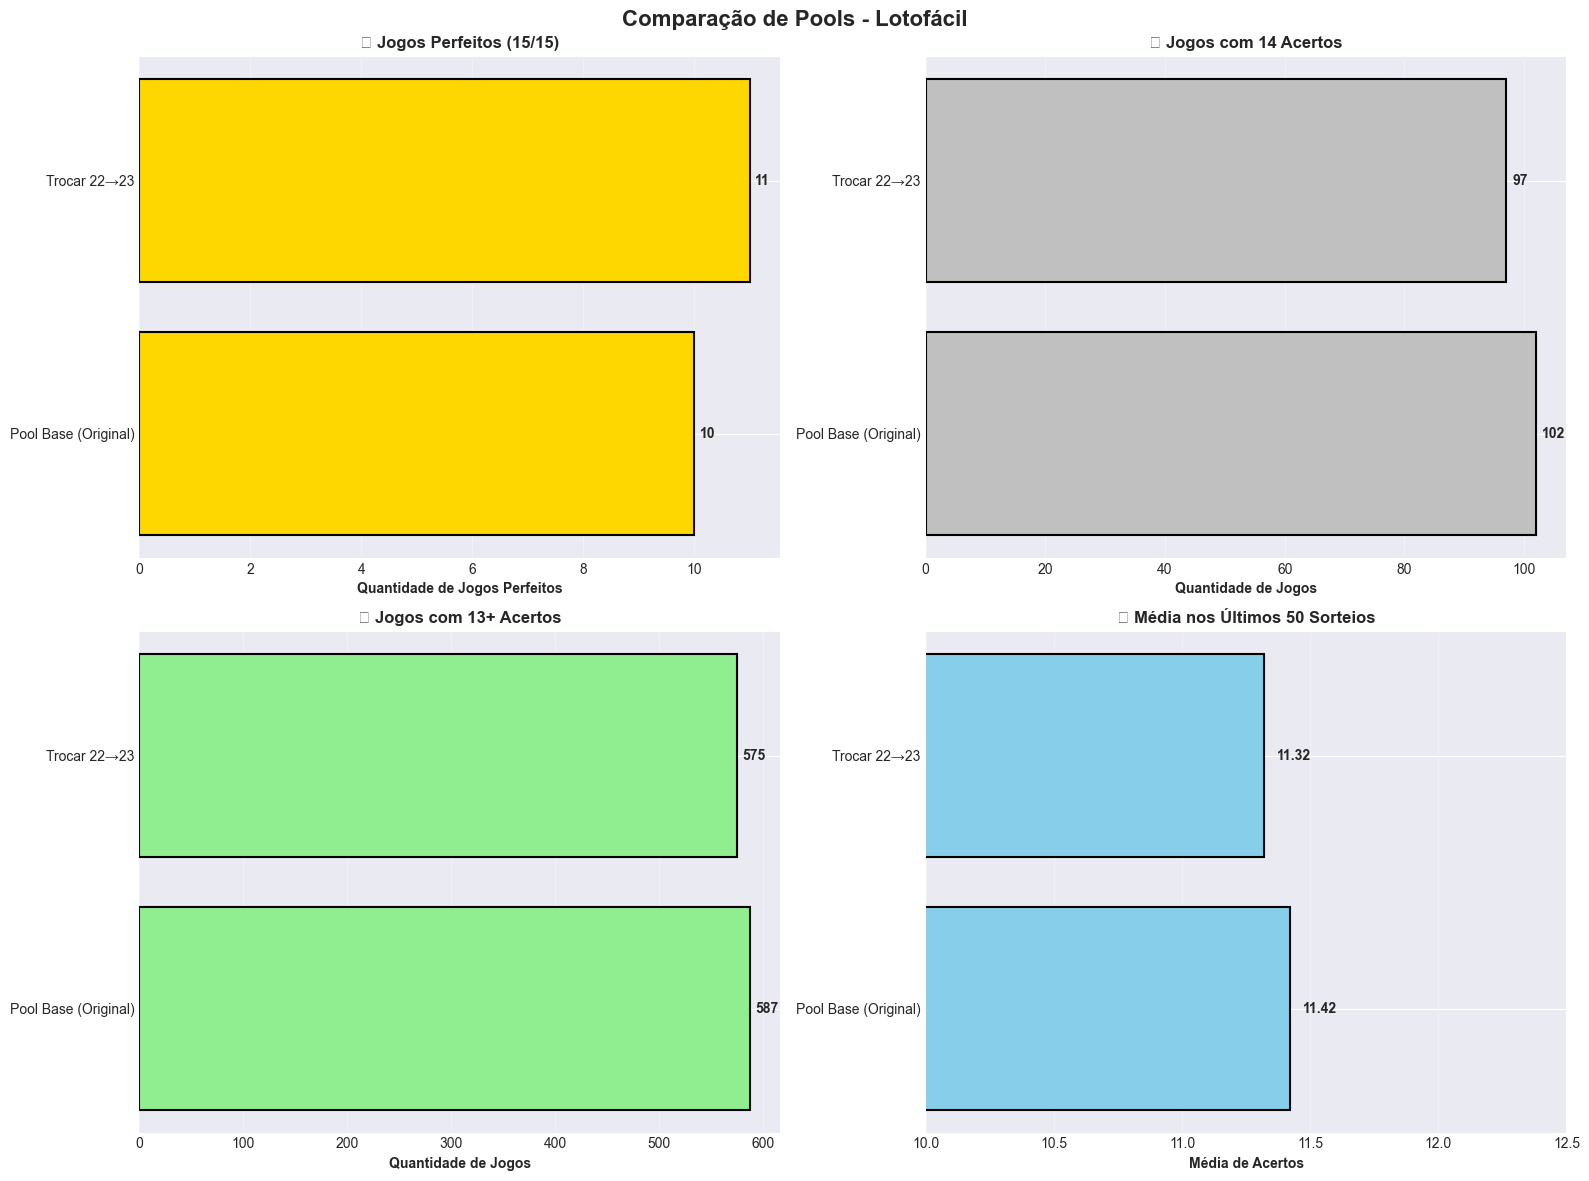


📊 Gráficos gerados com sucesso!


In [12]:
# Preparar dados para visualização
nomes = [r['nome'] for r in resultados_comparacao]
perfeitos = [r['perfeitos'] for r in resultados_comparacao]
jogos_14 = [r['jogos_14'] for r in resultados_comparacao]
jogos_13_plus = [r['jogos_13_plus'] for r in resultados_comparacao]
media_50 = [r['media_ultimos_50'] for r in resultados_comparacao]

# Criar figura com subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Pools - Lotofácil', fontsize=16, fontweight='bold')

# Gráfico 1: Jogos Perfeitos (15/15)
ax1 = axes[0, 0]
bars1 = ax1.barh(nomes, perfeitos, color='gold', edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Quantidade de Jogos Perfeitos', fontweight='bold')
ax1.set_title('🏆 Jogos Perfeitos (15/15)', fontweight='bold', fontsize=12)
ax1.grid(axis='x', alpha=0.3)
# Adicionar valores nas barras
for i, (bar, val) in enumerate(zip(bars1, perfeitos)):
    ax1.text(val + 0.1, i, str(val), va='center', fontweight='bold')

# Gráfico 2: 14 Acertos
ax2 = axes[0, 1]
bars2 = ax2.barh(nomes, jogos_14, color='silver', edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Quantidade de Jogos', fontweight='bold')
ax2.set_title('⭐ Jogos com 14 Acertos', fontweight='bold', fontsize=12)
ax2.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars2, jogos_14)):
    ax2.text(val + 1, i, str(val), va='center', fontweight='bold')

# Gráfico 3: 13+ Acertos
ax3 = axes[1, 0]
bars3 = ax3.barh(nomes, jogos_13_plus, color='lightgreen', edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Quantidade de Jogos', fontweight='bold')
ax3.set_title('✅ Jogos com 13+ Acertos', fontweight='bold', fontsize=12)
ax3.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars3, jogos_13_plus)):
    ax3.text(val + 5, i, str(val), va='center', fontweight='bold')

# Gráfico 4: Média Últimos 50
ax4 = axes[1, 1]
bars4 = ax4.barh(nomes, media_50, color='skyblue', edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Média de Acertos', fontweight='bold')
ax4.set_title('📈 Média nos Últimos 50 Sorteios', fontweight='bold', fontsize=12)
ax4.set_xlim(10, 12.5)
ax4.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars4, media_50)):
    ax4.text(val + 0.05, i, f'{val:.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Gráficos gerados com sucesso!")

## 7️⃣ Tabela Comparativa Detalhada

Comparação lado a lado de todos os pools testados

In [14]:
# Criar tabela comparativa
comparacao_data = []

for res in resultados_comparacao:
    comparacao_data.append({
        'Pool': res['nome'],
        '15 Acertos': res['perfeitos'],
        '14 Acertos': res['jogos_14'],
        '13+ Acertos': res['jogos_13_plus'],
        '13+ (%)': f"{res['jogos_13_plus_pct']:.2f}%",
        'Média Geral': f"{res['media_geral']:.2f}",
        'Média Ú50': f"{res['media_ultimos_50']:.2f}",
        'Média Ú20': f"{res['media_ultimos_20']:.2f}"
    })

df_comparacao = pd.DataFrame(comparacao_data)

print("="*120)
print("📊 TABELA COMPARATIVA DE POOLS")
print("="*120)
print()

# Exibir tabela
display(df_comparacao)

# Identificar os melhores em cada categoria
print("\n🌟 DESTAQUES:")
melhor_15 = df_comparacao.loc[df_comparacao['15 Acertos'].idxmax(), 'Pool']
melhor_14 = df_comparacao.loc[df_comparacao['14 Acertos'].idxmax(), 'Pool']
melhor_13plus = df_comparacao.loc[df_comparacao['13+ Acertos'].idxmax(), 'Pool']

print(f"   🏆 Mais jogos perfeitos (15): {melhor_15} ({df_comparacao['15 Acertos'].max()})")
print(f"   ⭐ Mais 14 acertos: {melhor_14} ({df_comparacao['14 Acertos'].max()})")
print(f"   ✅ Mais 13+ acertos: {melhor_13plus} ({df_comparacao['13+ Acertos'].max()})")

print("\n" + "="*120)
print("🏆 MELHOR POOL:")
# Encontrar o pool com mais jogos perfeitos
melhor_idx = df_comparacao['15 Acertos'].astype(int).idxmax()
melhor_pool = resultados_comparacao[melhor_idx]

print(f"\n   Nome: {melhor_pool['nome']}")
print(f"   Números: {melhor_pool['pool']}")
print(f"   Jogos Perfeitos: {melhor_pool['perfeitos']}")
print(f"   13+ Acertos: {melhor_pool['jogos_13_plus']} ({melhor_pool['jogos_13_plus_pct']:.2f}%)")
print(f"   Média Últimos 50: {melhor_pool['media_ultimos_50']:.2f}/15")
print("="*120)

📊 TABELA COMPARATIVA DE POOLS



,Pool,15 Acertos,14 Acertos,13+ Acertos,13+ (%),Média Geral,Média Ú50,Média Ú20
0,Pool Base (Original),10,102,587,16.42%,11.48,11.42,11.70
1,Trocar 22→23,11,97,575,16.08%,11.47,11.32,11.60



🌟 DESTAQUES:
   🏆 Mais jogos perfeitos (15): Trocar 22→23 (11)
   ⭐ Mais 14 acertos: Pool Base (Original) (102)
   ✅ Mais 13+ acertos: Pool Base (Original) (587)

🏆 MELHOR POOL:

   Nome: Trocar 22→23
   Números: [1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 23, 24, 25]
   Jogos Perfeitos: 11
   13+ Acertos: 575 (16.08%)
   Média Últimos 50: 11.32/15


## 8️⃣ Análise Individual de Número

Teste o impacto de adicionar ou remover um número específico

In [15]:
# Configure aqui: qual número testar e se adicionar ou remover
NUMERO_TESTAR = 23
ACAO = "adicionar"  # "adicionar" ou "remover"

# Pool de referência (pode ser o pool ótimo ou seu pool atual)
POOL_REF = [1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]

print(f"🔍 Testando impacto de {ACAO.upper()} o número {NUMERO_TESTAR}")
print(f"\n📋 Pool de referência ({len(POOL_REF)} números): {sorted(POOL_REF)}")

# Criar pool modificado
if ACAO == "adicionar":
    if NUMERO_TESTAR in POOL_REF:
        print(f"\n⚠️  Número {NUMERO_TESTAR} já está no pool!")
    else:
        if len(POOL_REF) >= 19:
            print(f"\n⚠️  Pool já tem {len(POOL_REF)} números. Precisa remover um para adicionar outro.")
        else:
            pool_modificado = sorted(POOL_REF + [NUMERO_TESTAR])
            print(f"\n✅ Pool modificado ({len(pool_modificado)} números): {pool_modificado}")
            
            # Analisar ambos
            res_ref = analisar_pool(POOL_REF, df.copy(), "Pool Referência")
            res_mod = analisar_pool(pool_modificado, df.copy(), f"Pool + {NUMERO_TESTAR}")
            
            # Comparar
            print("\n" + "="*70)
            print("📊 COMPARAÇÃO")
            print("="*70)
            print(f"\n{'Métrica':<25} {'Referência':>15} {'+ {}'.format(NUMERO_TESTAR):>15} {'Diferença':>15}")
            print("-"*70)
            print(f"{'Jogos Perfeitos (15)':<25} {res_ref['perfeitos']:>15} {res_mod['perfeitos']:>15} {res_mod['perfeitos']-res_ref['perfeitos']:>+15}")
            print(f"{'14 Acertos':<25} {res_ref['jogos_14']:>15} {res_mod['jogos_14']:>15} {res_mod['jogos_14']-res_ref['jogos_14']:>+15}")
            print(f"{'13+ Acertos':<25} {res_ref['jogos_13_plus']:>15} {res_mod['jogos_13_plus']:>15} {res_mod['jogos_13_plus']-res_ref['jogos_13_plus']:>+15}")
            print(f"{'Média Geral':<25} {res_ref['media_geral']:>15.2f} {res_mod['media_geral']:>15.2f} {res_mod['media_geral']-res_ref['media_geral']:>+15.2f}")
            print(f"{'Média Últ. 50':<25} {res_ref['media_ultimos_50']:>15.2f} {res_mod['media_ultimos_50']:>15.2f} {res_mod['media_ultimos_50']-res_ref['media_ultimos_50']:>+15.2f}")
            print("="*70)
            
            # Recomendação
            if res_mod['perfeitos'] > res_ref['perfeitos']:
                print(f"\n✅ RECOMENDAÇÃO: ADICIONAR {NUMERO_TESTAR} (ganha {res_mod['perfeitos']-res_ref['perfeitos']} jogo(s) perfeito(s))")
            elif res_mod['perfeitos'] < res_ref['perfeitos']:
                print(f"\n❌ RECOMENDAÇÃO: NÃO ADICIONAR {NUMERO_TESTAR} (perde {res_ref['perfeitos']-res_mod['perfeitos']} jogo(s) perfeito(s))")
            else:
                print(f"\n⚖️  RECOMENDAÇÃO: NEUTRO (mesma quantidade de jogos perfeitos)")

elif ACAO == "remover":
    if NUMERO_TESTAR not in POOL_REF:
        print(f"\n⚠️  Número {NUMERO_TESTAR} não está no pool!")
    else:
        pool_modificado = [n for n in POOL_REF if n != NUMERO_TESTAR]
        print(f"\n✅ Pool modificado ({len(pool_modificado)} números): {sorted(pool_modificado)}")
        
        # Analisar ambos
        res_ref = analisar_pool(POOL_REF, df.copy(), "Pool Referência")
        res_mod = analisar_pool(pool_modificado, df.copy(), f"Pool - {NUMERO_TESTAR}")
        
        # Comparar
        print("\n" + "="*70)
        print("📊 COMPARAÇÃO")
        print("="*70)
        print(f"\n{'Métrica':<25} {'Referência':>15} {'- {}'.format(NUMERO_TESTAR):>15} {'Diferença':>15}")
        print("-"*70)
        print(f"{'Jogos Perfeitos (15)':<25} {res_ref['perfeitos']:>15} {res_mod['perfeitos']:>15} {res_mod['perfeitos']-res_ref['perfeitos']:>+15}")
        print(f"{'14 Acertos':<25} {res_ref['jogos_14']:>15} {res_mod['jogos_14']:>15} {res_mod['jogos_14']-res_ref['jogos_14']:>+15}")
        print(f"{'13+ Acertos':<25} {res_ref['jogos_13_plus']:>15} {res_mod['jogos_13_plus']:>15} {res_mod['jogos_13_plus']-res_ref['jogos_13_plus']:>+15}")
        print(f"{'Média Geral':<25} {res_ref['media_geral']:>15.2f} {res_mod['media_geral']:>15.2f} {res_mod['media_geral']-res_ref['media_geral']:>+15.2f}")
        print(f"{'Média Últ. 50':<25} {res_ref['media_ultimos_50']:>15.2f} {res_mod['media_ultimos_50']:>15.2f} {res_mod['media_ultimos_50']-res_ref['media_ultimos_50']:>+15.2f}")
        print("="*70)
        
        # Recomendação
        if res_mod['perfeitos'] < res_ref['perfeitos']:
            print(f"\n❌ RECOMENDAÇÃO: NÃO REMOVER {NUMERO_TESTAR} (perderia {res_ref['perfeitos']-res_mod['perfeitos']} jogo(s) perfeito(s))")
        elif res_mod['perfeitos'] > res_ref['perfeitos']:
            print(f"\n✅ RECOMENDAÇÃO: REMOVER {NUMERO_TESTAR} (ganha {res_mod['perfeitos']-res_ref['perfeitos']} jogo(s) perfeito(s))")
        else:
            print(f"\n⚖️  RECOMENDAÇÃO: NEUTRO (mesma quantidade de jogos perfeitos)")

🔍 Testando impacto de ADICIONAR o número 23

📋 Pool de referência (19 números): [1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]

⚠️  Pool já tem 19 números. Precisa remover um para adicionar outro.


## 9️⃣ Teste Rápido: Trocar Um por Outro

Teste rapidamente a troca de um número por outro (ex: 22→23)

In [ ]:
# 🔄 CONFIGURAÇÃO DA TROCA
NUMERO_SAI = 22
NUMERO_ENTRA = 23

# Pool atual
POOL_ATUAL = [1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 18, 19, 20, 21, 22, 24, 25]

print(f"🔄 TESTE DE TROCA: {NUMERO_SAI} → {NUMERO_ENTRA}")
print("="*70)

# Validar
if NUMERO_SAI not in POOL_ATUAL:
    print(f"\n❌ Número {NUMERO_SAI} não está no pool atual!")
elif NUMERO_ENTRA in POOL_ATUAL:
    print(f"\n❌ Número {NUMERO_ENTRA} já está no pool atual!")
else:
    # Criar pool modificado
    pool_novo = [n if n != NUMERO_SAI else NUMERO_ENTRA for n in POOL_ATUAL]
    
    print(f"\n📋 Pool Atual:  {sorted(POOL_ATUAL)}")
    print(f"📋 Pool Novo:   {sorted(pool_novo)}")
    print(f"\n🔴 Sai:  {NUMERO_SAI}")
    print(f"🟢 Entra: {NUMERO_ENTRA}")
    
    # Analisar
    print("\n⏳ Analisando pools...")
    res_atual = analisar_pool(POOL_ATUAL, df.copy(), "Pool Atual")
    res_novo = analisar_pool(pool_novo, df.copy(), f"Pool ({NUMERO_SAI}→{NUMERO_ENTRA})")
    
    # Resultados
    print("\n" + "="*70)
    print("📊 RESULTADOS DA TROCA")
    print("="*70)
    
    print(f"\n{'Métrica':<25} {'Pool Atual':>15} {'Pool Novo':>15} {'Diferença':>15}")
    print("-"*70)
    print(f"{'🏆 Jogos Perfeitos (15)':<25} {res_atual['perfeitos']:>15} {res_novo['perfeitos']:>15} {res_novo['perfeitos']-res_atual['perfeitos']:>+15}")
    print(f"{'⭐ 14 Acertos':<25} {res_atual['jogos_14']:>15} {res_novo['jogos_14']:>15} {res_novo['jogos_14']-res_atual['jogos_14']:>+15}")
    print(f"{'✅ 13+ Acertos':<25} {res_atual['jogos_13_plus']:>15} {res_novo['jogos_13_plus']:>15} {res_novo['jogos_13_plus']-res_ref['jogos_13_plus']:>+15}")
    print(f"{'📈 Média Geral':<25} {res_atual['media_geral']:>15.2f} {res_novo['media_geral']:>15.2f} {res_novo['media_geral']-res_atual['media_geral']:>+15.2f}")
    print(f"{'📊 Média Últ. 50':<25} {res_atual['media_ultimos_50']:>15.2f} {res_novo['media_ultimos_50']:>15.2f} {res_novo['media_ultimos_50']-res_atual['media_ultimos_50']:>+15.2f}")
    print(f"{'📉 Média Últ. 20':<25} {res_atual['media_ultimos_20']:>15.2f} {res_novo['media_ultimos_20']:>15.2f} {res_novo['media_ultimos_20']-res_atual['media_ultimos_20']:>+15.2f}")
    
    print("\n" + "="*70)
    
    # Análise de impacto
    diff_perfeitos = res_novo['perfeitos'] - res_atual['perfeitos']
    diff_13plus = res_novo['jogos_13_plus'] - res_atual['jogos_13_plus']
    diff_media50 = res_novo['media_ultimos_50'] - res_atual['media_ultimos_50']
    
    print("\n🎯 RECOMENDAÇÃO:")
    
    if diff_perfeitos > 0:
        print(f"   ✅ VANTAJOSO! Ganha {diff_perfeitos} jogo(s) perfeito(s)")
    elif diff_perfeitos < 0:
        print(f"   ❌ DESVANTAJOSO! Perde {abs(diff_perfeitos)} jogo(s) perfeito(s)")
    else:
        print(f"   ⚖️  NEUTRO em jogos perfeitos")
        
        if diff_13plus > 0:
            print(f"   ✅ Mas ganha {diff_13plus} jogos com 13+ acertos")
        elif diff_13plus < 0:
            print(f"   ❌ E perde {abs(diff_13plus)} jogos com 13+ acertos")
        
        if diff_media50 > 0:
            print(f"   ✅ Melhora média nos últimos 50 (+{diff_media50:.2f})")
        elif diff_media50 < 0:
            print(f"   ❌ Piora média nos últimos 50 ({diff_media50:.2f})")
    
    print("="*70)